# 29 -- Paper figures

All numbers come from `paper_data.py` and are cached in `data/paper_cache/` (set `REBUILD = True`, or delete a cache file, to recompute one).
Conventions are listed in `paper_data.py`'s docstring: (A+B)/2 lattice spectra; wall_points=100 pair-spectrum scans at each run's exact
$\bar\lambda$; our BubbleMaster cutoff window; $\hat D^{3.6}$ damping; lattice-vs-surrogate comparisons through the lattice shell estimator;
$I_{\mathcal K}=\sum_n P_n\,\Delta k/k_n$ over shells with $kR_*\le100$. Figures go to `notebooks/plots/paper/`.

In [156]:
#%pip install -e ../.

In [222]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
from matplotlib import rc, rcParams
from matplotlib.colors import LogNorm
from matplotlib.ticker import FixedLocator, NullLocator

import paper_data as P

# ---------------------------------------------------------------- global settings
REBUILD = False                  # True: recompute every cache (slow); or delete one file in data/paper_cache/

TEXTWIDTH = 7.0                  # inches; figure spans both columns (check with \the\textwidth in the paper)
FONTSIZE = 9                     # pt, all text in every figure (caption size)
LEGEND_FONTSIZE = 8              # pt, legends (plain text reads larger than the maths labels)

LW = 1.0                         # main line width
LW_THIN = 0.75                   # secondary lines (ratios, dashed surrogates)
LS_UNDAMPED = ':'               # undamped surrogate (dotted is taken by the ratio = 1 line)

OUT = P.ROOT / 'notebooks' / 'plots' / 'paper'
OUT.mkdir(parents=True, exist_ok=True)

# on-screen display only (the saved PDFs are vector graphics at the print size above)
%config InlineBackend.figure_format = 'retina'
DISPLAY_DPI = 150                # larger number = larger figure in the notebook
rcParams['figure.dpi'] = DISPLAY_DPI
rcParams['savefig.dpi'] = 300    # resolution of the rasterized layers (heatmaps) inside the PDFs

rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rcParams['text.usetex'] = True
rcParams.update({
    'font.size': FONTSIZE,
    'axes.labelsize': FONTSIZE,
    'axes.titlesize': FONTSIZE,
    'legend.fontsize': LEGEND_FONTSIZE,
    'xtick.labelsize': FONTSIZE,
    'ytick.labelsize': FONTSIZE,
    'legend.handlelength': 1.2,
    'legend.handletextpad': 0.5,
    'legend.labelspacing': 0.3,
    'legend.borderaxespad': 0.3,
})

# ---------------------------------------------------------------- shared labels and colours
YLAB = r'$[H_*R_*\Omega_{\rm vac}]^{-2}\,d\Omega_{\rm GW}/d\ln k$'
YLAB_RATIO_SPEC = r'$\mathcal{P}^{\rm sur}_{\rm GW}/\mathcal{P}^{\rm lat}_{\rm GW}$'   # surrogate / lattice (lattice = reference)
YLAB_RATIO_IK = r'$I^{\rm sur}_{\mathcal{K}}/I^{\rm lat}_{\mathcal{K}}$'

COL3 = ['#0072B2', '#D55E00', '#009E73']          # the three pairs of each N_b=2/3 configuration
LB_LABEL = {0.84: '0.84', 0.069: '0.069', P.LB845: '0.845'}
WALL = {0.84: 'thin', 0.069: 'thick', P.LB845: 'thin'}   # "<wall> bubbles" in panel labels;
                                                        # NB: Cutting et al. call lambda_bar >= 0.84 thin-wall


def ticks(ax):
    ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)


def panel_label(ax, lb, extra=''):
    """Bold wall type, lambda_bar and an optional suffix, as the panel title."""
    ax.set_title(rf'\textbf{{{WALL[lb]} wall}} ($\bar\lambda={LB_LABEL[lb]}$)' + extra)


def hide_join_label(ax, x=1.0):
    """Hide the tick label at x in a right-hand column (it would collide with the left column's last label)."""
    ax.figure.canvas.draw()
    for t in ax.xaxis.get_major_ticks():
        if abs(t.get_loc() - x) < 1e-9:
            t.label1.set_visible(False)

## Fig. 1 -- $N_b=2$ spectra at $t/R_*\simeq1.095$ (lattice snapshot nearest $t_m$; surrogate at that time)

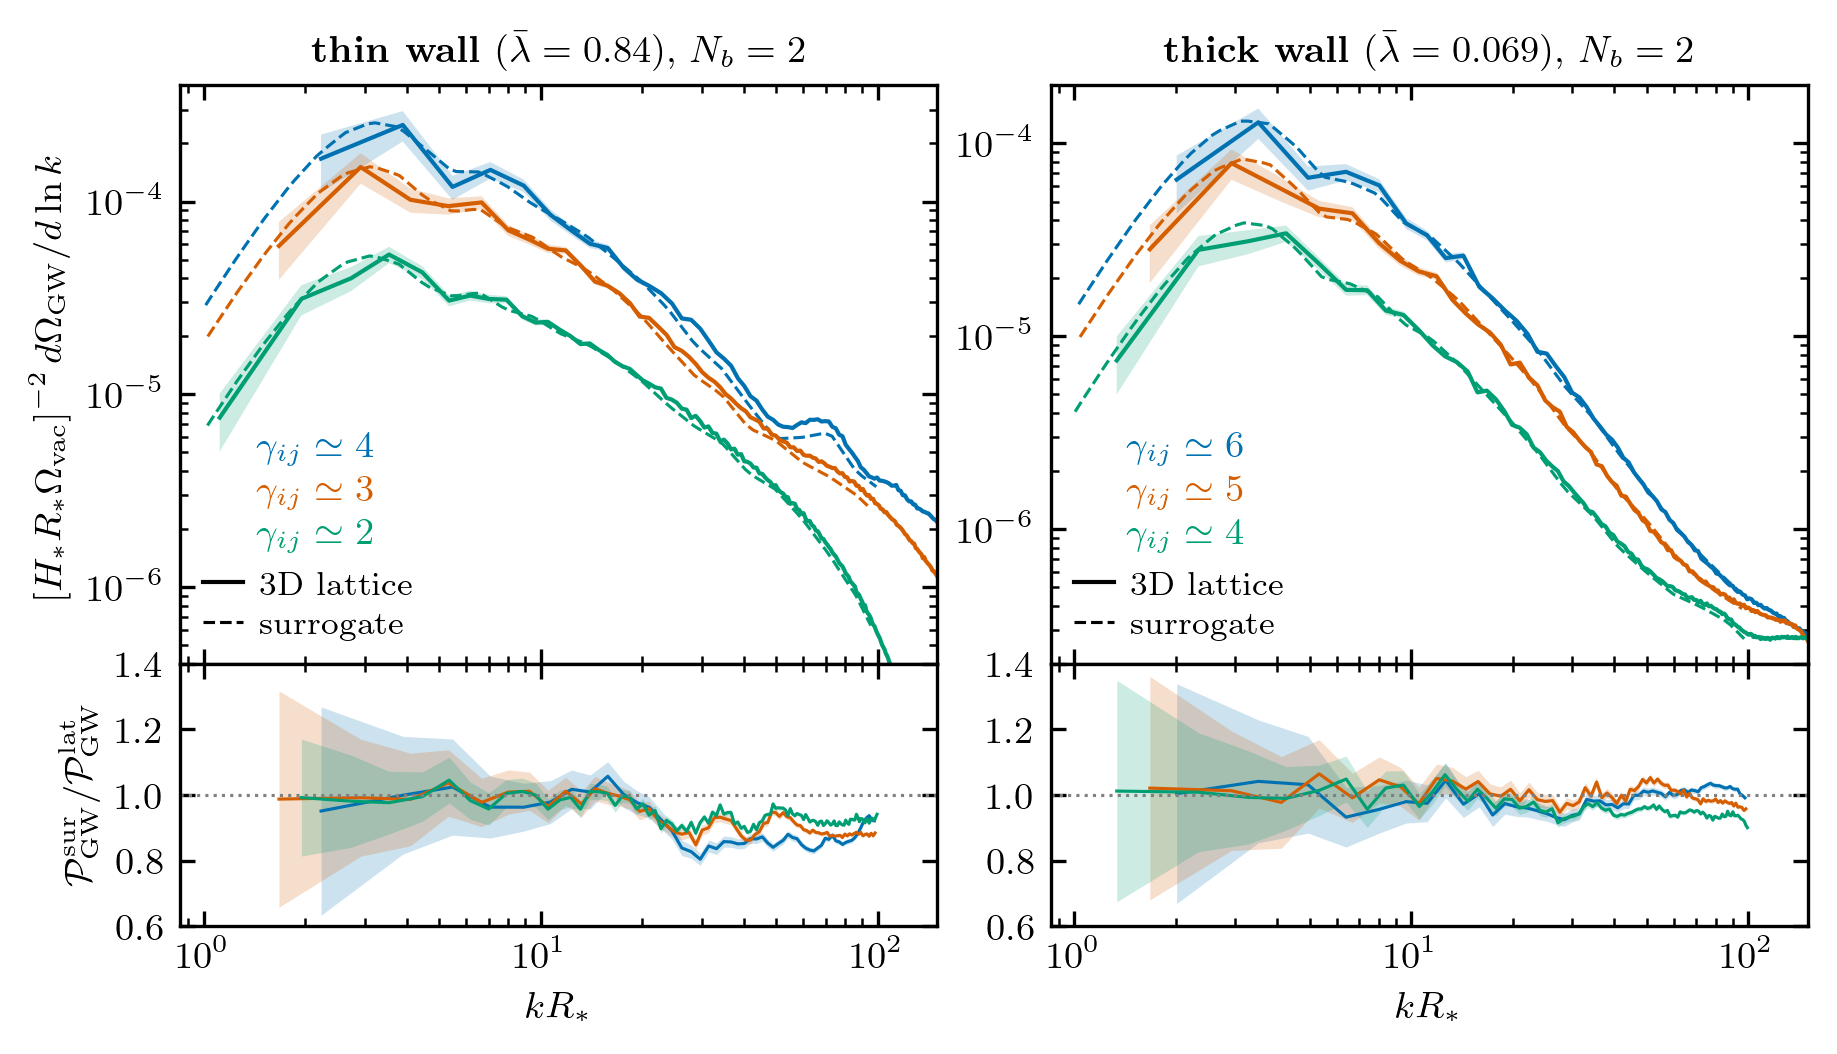

(0.84, (0, 1)) gamma=4.007: lattice snapshot t/R_*=1.086
(0.84, (0, 2)) gamma=3.006: lattice snapshot t/R_*=1.111
(0.84, (1, 2)) gamma=2.006: lattice snapshot t/R_*=1.086
(0.069, (0, 1)) gamma=6.001: lattice snapshot t/R_*=1.086
(0.069, (0, 2)) gamma=5.003: lattice snapshot t/R_*=1.102
(0.069, (1, 2)) gamma=4.001: lattice snapshot t/R_*=1.091


In [223]:
n2 = P.cached('fig12_n2', P.build_n2, REBUILD)

# ---------------------------------------------------------------- settings
FIGSIZE = (TEXTWIDTH, 0.52 * TEXTWIDTH)
HEIGHT_RATIOS = [2.2, 1]

XLIM = (0.85, 150)
YLIM = {0.84: (4e-7, 4e-4),          # spectra, per column (each has its own y-axis)
        0.069: (2e-7, 2e-4)}
YLIM_RATIO = {0.84: (0.6, 1.4),      # ratio, per column
              0.069: (0.6, 1.4)}
YTICKS_RATIO = {0.84: [0.6, 0.8, 1.0, 1.2, 1.4],
                0.069: [0.6, 0.8, 1.0, 1.2, 1.4]}

#GAMMA_LABEL_X0 = np.array([[0.98, 0.98, 0.98], [0.46, 0.32, 0.28]])
#GAMMA_LABEL_Y0 = np.array([[0.98, 0.83, 0.67], [0.9, 0.765, 0.6]])
GAMMA_LABEL_X = 0.1                # gamma_coll labels: left, below the legend
GAMMA_LABEL_Y0 = 0.4
GAMMA_LABEL_DY = 0.075
LEGEND_LOC = 'lower left'

# ---------------------------------------------------------------- figure
fig, axes = plt.subplots(
    2, 2, figsize=FIGSIZE, sharex='col',
    gridspec_kw=dict(height_ratios=HEIGHT_RATIOS, hspace=0, wspace=0.15),
)

for col, lb in enumerate([0.84, 0.069]):
    a, b = axes[:, col]
    pairs = [(k, v) for k, v in n2.items() if k[0] == lb]

    for (key, r), cc in zip(pairs, COL3):
        # spectra: lattice with mode-counting band, surrogate dashed
        a.plot(r['kR_sh'], r['y_sh'], color=cc, lw=LW)
        a.fill_between(r['kR_sh'], np.maximum(r['y_sh'] - r['yerr'], 1e-300), r['y_sh'] + r['yerr'],
                       color=cc, alpha=0.2, lw=0)
        m = (r['kR_rec'] >= 1) & (r['kR_rec'] <= 100)
        a.plot(r['kR_rec'][m], r['y_rec'][m], color=cc, lw=LW_THIN, ls='--')

        # ratio through the lattice shell estimator
        x = r['kR_sh'][r['shell_mask']]
        y = r['rec_shells'] / r['y_sh'][r['shell_mask']]                       # surrogate / lattice
        e = y * r['yerr'][r['shell_mask']] / r['y_sh'][r['shell_mask']]        # lattice uncertainty, relative
        b.plot(x, y, color=cc, lw=LW_THIN)
        b.fill_between(x, y - e, y + e, color=cc, alpha=0.2, lw=0)

    # legend and labels
    a.plot([], [], color='black', lw=LW, label='3D lattice')
    a.plot([], [], color='black', lw=LW_THIN, ls='--', label='surrogate')
    a.legend(frameon=False, loc=LEGEND_LOC)
    panel_label(a, lb, r', $N_b=2$')
    for i, ((key, r), cc) in enumerate(zip(pairs, COL3)):
        a.text(GAMMA_LABEL_X, GAMMA_LABEL_Y0 - GAMMA_LABEL_DY * i, rf"$\gamma_{{ij}}\simeq{round(r['gamma'])}$",
               color=cc, transform=a.transAxes, ha='left', va='top')

    # axes
    a.set_xscale('log')
    a.set_yscale('log')
    a.set_xlim(*XLIM)
    a.set_ylim(*YLIM[lb])
    
    b.axhline(1, color='gray', ls=':', lw=LW_THIN)
    b.set_ylim(*YLIM_RATIO[lb])
    b.set_yticks(YTICKS_RATIO[lb])
    b.set_xlabel(r'$kR_*$')

    for ax in (a, b):
        ticks(ax)

axes[0, 0].set_ylabel(YLAB)
axes[1, 0].set_ylabel(YLAB_RATIO_SPEC)

fig.savefig(OUT / 'n2_spectra.pdf', bbox_inches='tight')
plt.show()

for k, r in n2.items():
    print(k, f"gamma={r['gamma']:.3f}: lattice snapshot t/R_*={r['t_snap']/r['d']:.3f}")

## Fig. 2 -- $N_b=2$ integrated power $I_{\mathcal K}(t)$ up to the first periodic-image contact

/var/folders/kq/ng576v3n1kn_dcf_r3mgn1nw0000gn/T/ipykernel_77290/2646150883.py:32: RuntimeWarning: divide by zero encountered in divide
  b.plot(x[ok], (r['I_red'] / r['I_lat'])[ok], color=cc, lw=LW_THIN)


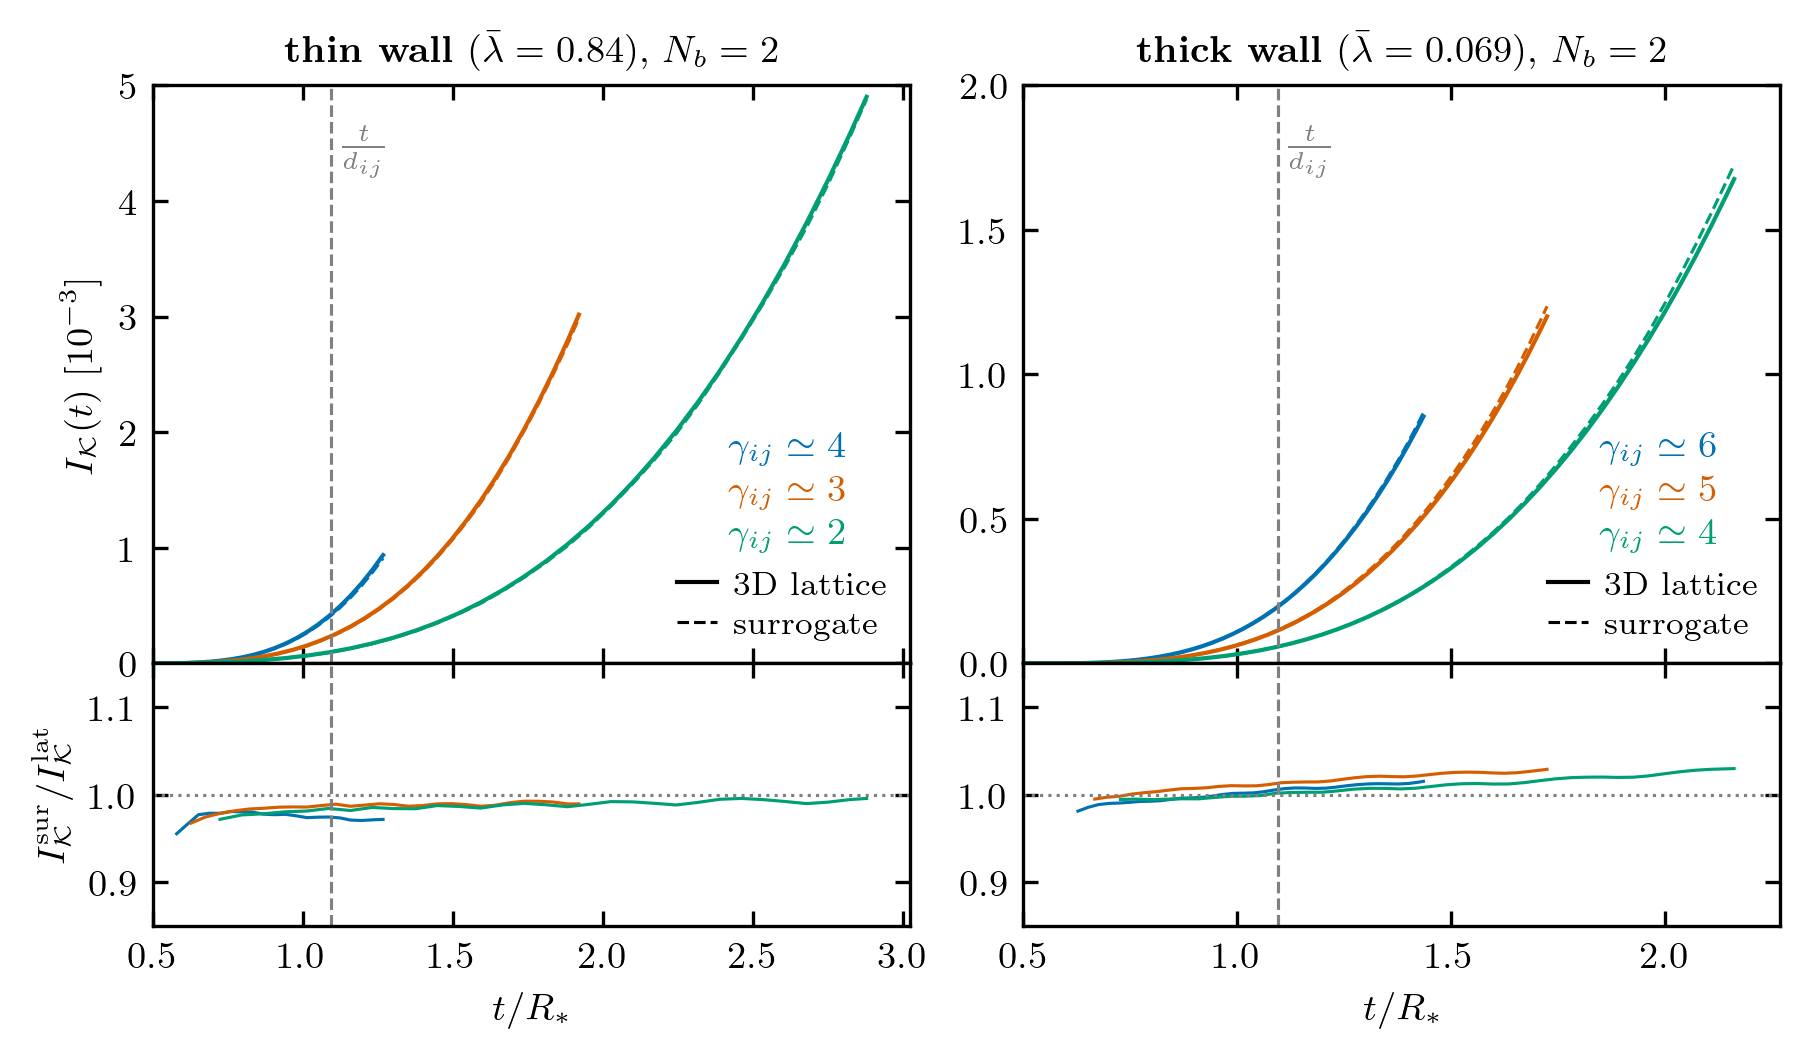

In [224]:
# ---------------------------------------------------------------- settings
FIGSIZE = (TEXTWIDTH, 0.52 * TEXTWIDTH)
HEIGHT_RATIOS = [2.2, 1]

T_FIG1 = 1.095                       # t/R_* of Fig. 1 (vertical line)
XLIM = (0.5, None)
YLIM = {0.84: (-1e-5, 5), 0.069: (-1e-5, 1.8)}    # I_K, per column (different scales)
YLIM_RATIO = (0.85, 1.15)
YTICKS_RATIO = [0.9, 1.0, 1.1]

GAMMA_LABEL_X = 0.76                 # gamma_coll labels: left, below the legend
GAMMA_LABEL_Y0 = 0.4
GAMMA_LABEL_DY = 0.075
LEGEND_LOC = 'lower right'
UNIT = 1e-3                          # I_K plotted in units of UNIT

# ---------------------------------------------------------------- figure
fig, axes = plt.subplots(
    2, 2, figsize=FIGSIZE, sharex='col', sharey='row' if False else False,
    gridspec_kw=dict(height_ratios=HEIGHT_RATIOS, hspace=0, wspace=0.15),
)

for col, lb in enumerate([0.84, 0.069]):
    a, b = axes[:, col]
    pairs = [(k, v) for k, v in n2.items() if k[0] == lb]

    for (key, r), cc in zip(pairs, COL3):
        x = r['t'] / r['d']
        a.plot(x, r['I_lat'] / UNIT, color=cc, lw=LW)
        a.plot(x, r['I_red'] / UNIT, color=cc, lw=LW_THIN, ls='--')
        ok = (r['I_lat'] > 1e-3 * r['I_lat'].max()) & (r['I_red'] > 1e-3 * r['I_lat'].max())
        b.plot(x[ok], (r['I_red'] / r['I_lat'])[ok], color=cc, lw=LW_THIN)

    # legend and labels
    a.plot([], [], color='black', lw=LW, label='3D lattice')
    a.plot([], [], color='black', lw=LW_THIN, ls='--', label='surrogate')
    a.legend(frameon=False, loc=LEGEND_LOC)
    panel_label(a, lb, r', $N_b=2$')
    for i, ((key, r), cc) in enumerate(zip(pairs, COL3)):
        a.text(GAMMA_LABEL_X, GAMMA_LABEL_Y0 - GAMMA_LABEL_DY * i, rf"$\gamma_{{ij}}\simeq{round(r['gamma'])}$",
               color=cc, transform=a.transAxes, ha='left', va='top')

    loc = [0.25, 0.35]
    a.text(loc[col], 0.88, r"$\frac{t}{d_{ij}}$", transform=a.transAxes, color='gray')
    
    # axes
    for ax in (a, b):
        ax.axvline(T_FIG1, color='gray', ls='--', lw=LW_THIN)
        ticks(ax)
    a.set_xlim(*XLIM)
    a.set_ylim(*YLIM[lb])
    a.set_yticks(a.get_yticks()[1:]) 
    #a.set_yscale('log')

    b.axhline(1, color='gray', ls=':', lw=LW_THIN)
    b.set_ylim(*YLIM_RATIO)
    b.set_yticks(YTICKS_RATIO)
    b.set_xlabel(r'$t/R_*$')

axes[0, 0].set_ylabel(r'$I_{\mathcal{K}}(t)\ [10^{-3}]$')
axes[1, 0].set_ylabel(YLAB_RATIO_IK)

fig.savefig(OUT / 'n2_integrated_power.pdf', bbox_inches='tight')
plt.show()

## Fig. 3 -- $N_b=3$ spectra (lattice snapshot nearest the latest pair $t_m$; damped surrogate at that time)

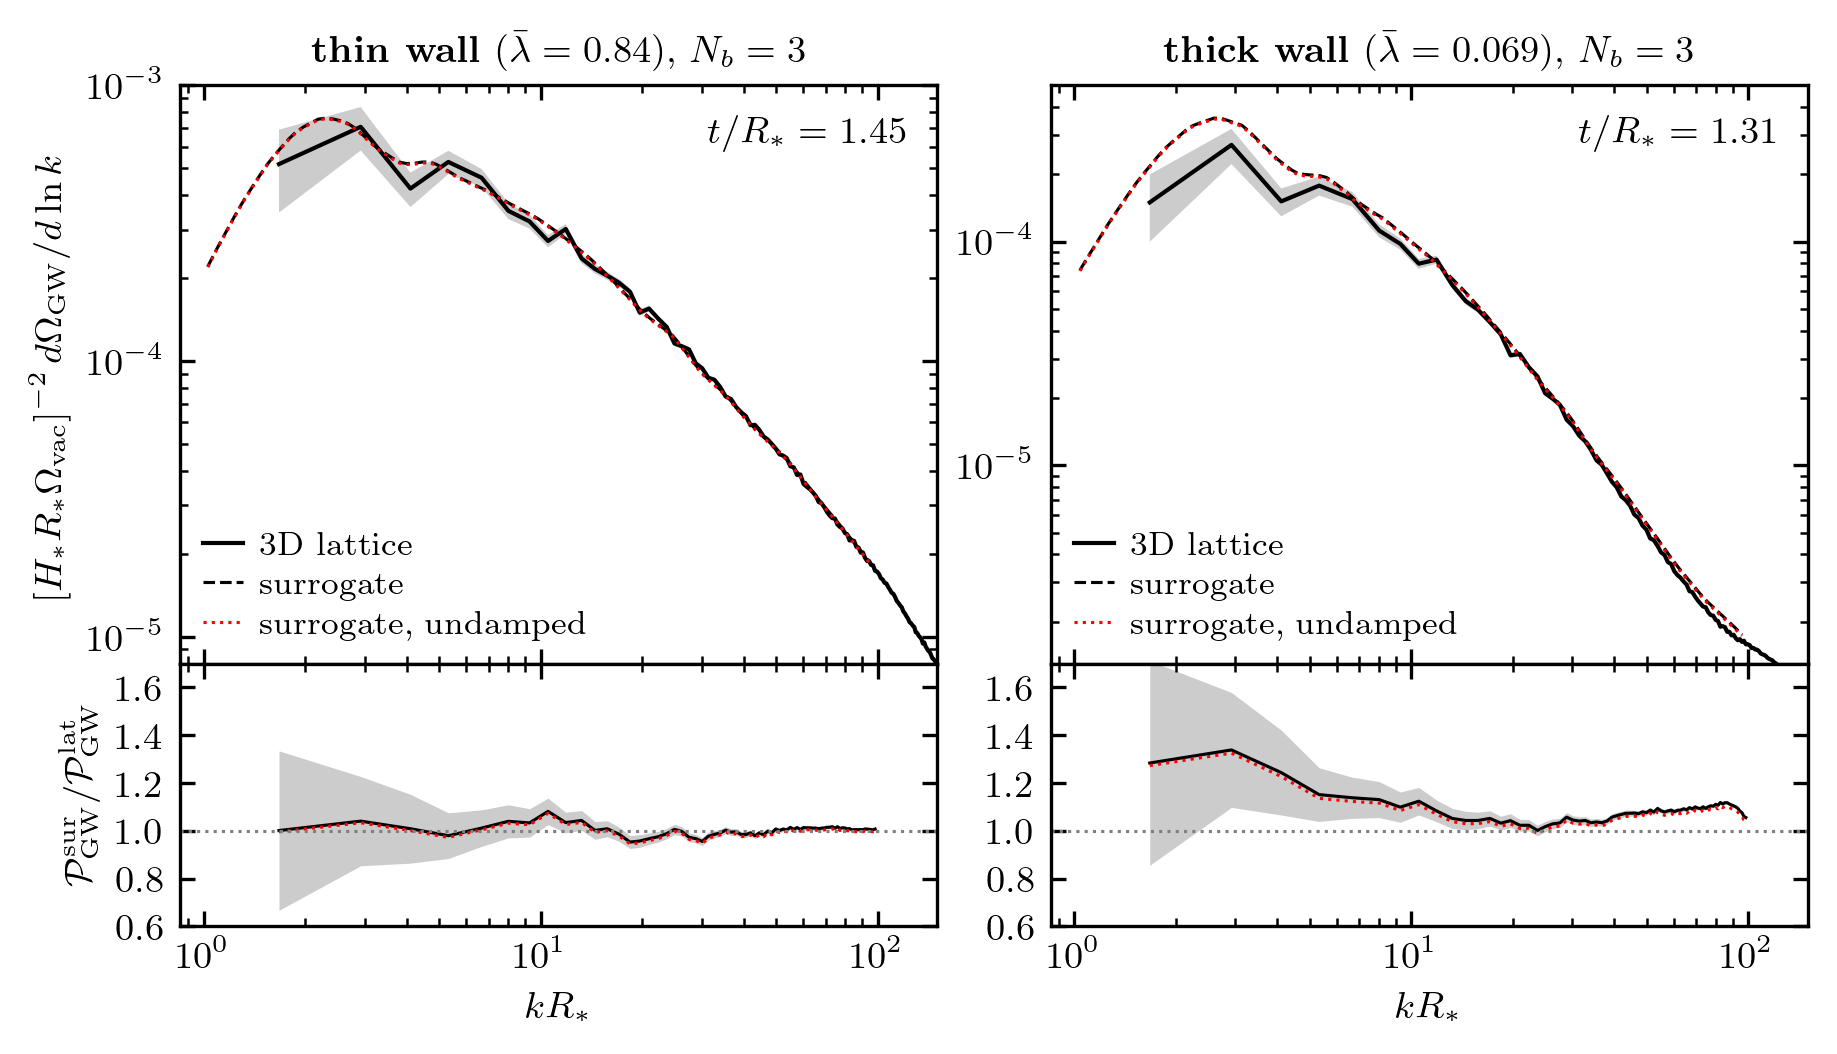

In [237]:
n3 = P.cached('fig3_n3', P.build_n3, REBUILD)

# ---------------------------------------------------------------- settings
FIGSIZE = (TEXTWIDTH, 0.52 * TEXTWIDTH)
HEIGHT_RATIOS = [2.2, 1]
COLOR = 'black'                      # one curve per panel

XLIM = (0.85, 150)
YLIM = {0.84: (8e-6, 1e-3),          # spectra, per column (each has its own y-axis)
        0.069: (1.3e-6, 5e-4)}
YLIM_RATIO = {0.84: (0.6, 1.7),      # ratio, per column
              0.069: (0.6, 1.7)}
YTICKS_RATIO = {0.84: [0.6, 0.8, 1.0, 1.2, 1.4, 1.6],
                0.069: [0.6, 0.8, 1.0, 1.2, 1.4, 1.6]}
LEGEND_LOC = 'lower left'

# ---------------------------------------------------------------- figure
fig, axes = plt.subplots(
    2, 2, figsize=FIGSIZE, sharex='col',
    gridspec_kw=dict(height_ratios=HEIGHT_RATIOS, hspace=0, wspace=0.15),
)

for col, lb in enumerate([0.84, 0.069]):
    a, b = axes[:, col]
    r = n3[lb]

    a.plot(r['kR_sh'], r['y_sh'], color=COLOR, lw=LW, label='3D lattice')
    a.fill_between(r['kR_sh'], np.maximum(r['y_sh'] - r['yerr'], 1e-300), r['y_sh'] + r['yerr'],
                   color=COLOR, alpha=0.2, lw=0)
    m = (r['kR_rec'] >= 1) & (r['kR_rec'] <= 100)
    a.plot(r['kR_rec'][m], r['y_rec'][m], color=COLOR, lw=LW_THIN, ls='--', label='surrogate')
    a.plot(r['kR_rec'][m], r['y_rec_raw'][m], color='red', lw=LW_THIN, ls=LS_UNDAMPED, label='surrogate, undamped')

    x = r['kR_sh'][r['shell_mask']]
    y = r['rec_shells'] / r['y_sh'][r['shell_mask']]               # surrogate / lattice
    e = y * r['yerr'][r['shell_mask']] / r['y_sh'][r['shell_mask']]    # lattice uncertainty, relative
    b.plot(x, y, color=COLOR, lw=LW_THIN)
    b.plot(x, r['rec_shells_raw'] / r['y_sh'][r['shell_mask']], color='red', lw=LW_THIN, ls=LS_UNDAMPED)
    b.fill_between(x, y - e, y + e, color=COLOR, alpha=0.2, lw=0)

    a.legend(frameon=False, loc=LEGEND_LOC)
    panel_label(a, lb, rf", $N_b=3$")
    a.text(0.96, 0.95, rf"$t/R_*={r['t_snap']/r['R']:.2f}$", transform=a.transAxes, ha='right', va='top')

    a.set_xscale('log')
    a.set_yscale('log')
    a.set_xlim(*XLIM)
    a.set_ylim(*YLIM[lb])

    b.axhline(1, color='gray', ls=':', lw=LW_THIN)
    b.set_ylim(*YLIM_RATIO[lb])
    b.set_yticks(YTICKS_RATIO[lb])
    b.set_xlabel(r'$kR_*$')

    for ax in (a, b):
        ticks(ax)

axes[0, 0].set_ylabel(YLAB)
axes[1, 0].set_ylabel(YLAB_RATIO_SPEC)

fig.savefig(OUT / 'n3_spectra.pdf', bbox_inches='tight')
plt.show()

## Figs. 4 and 5 -- $N_b>3$: late-time spectra and integrated power, with ratios ($\gamma_*=4,5,6$; $\bar\lambda=0.845$ and $0.069$)

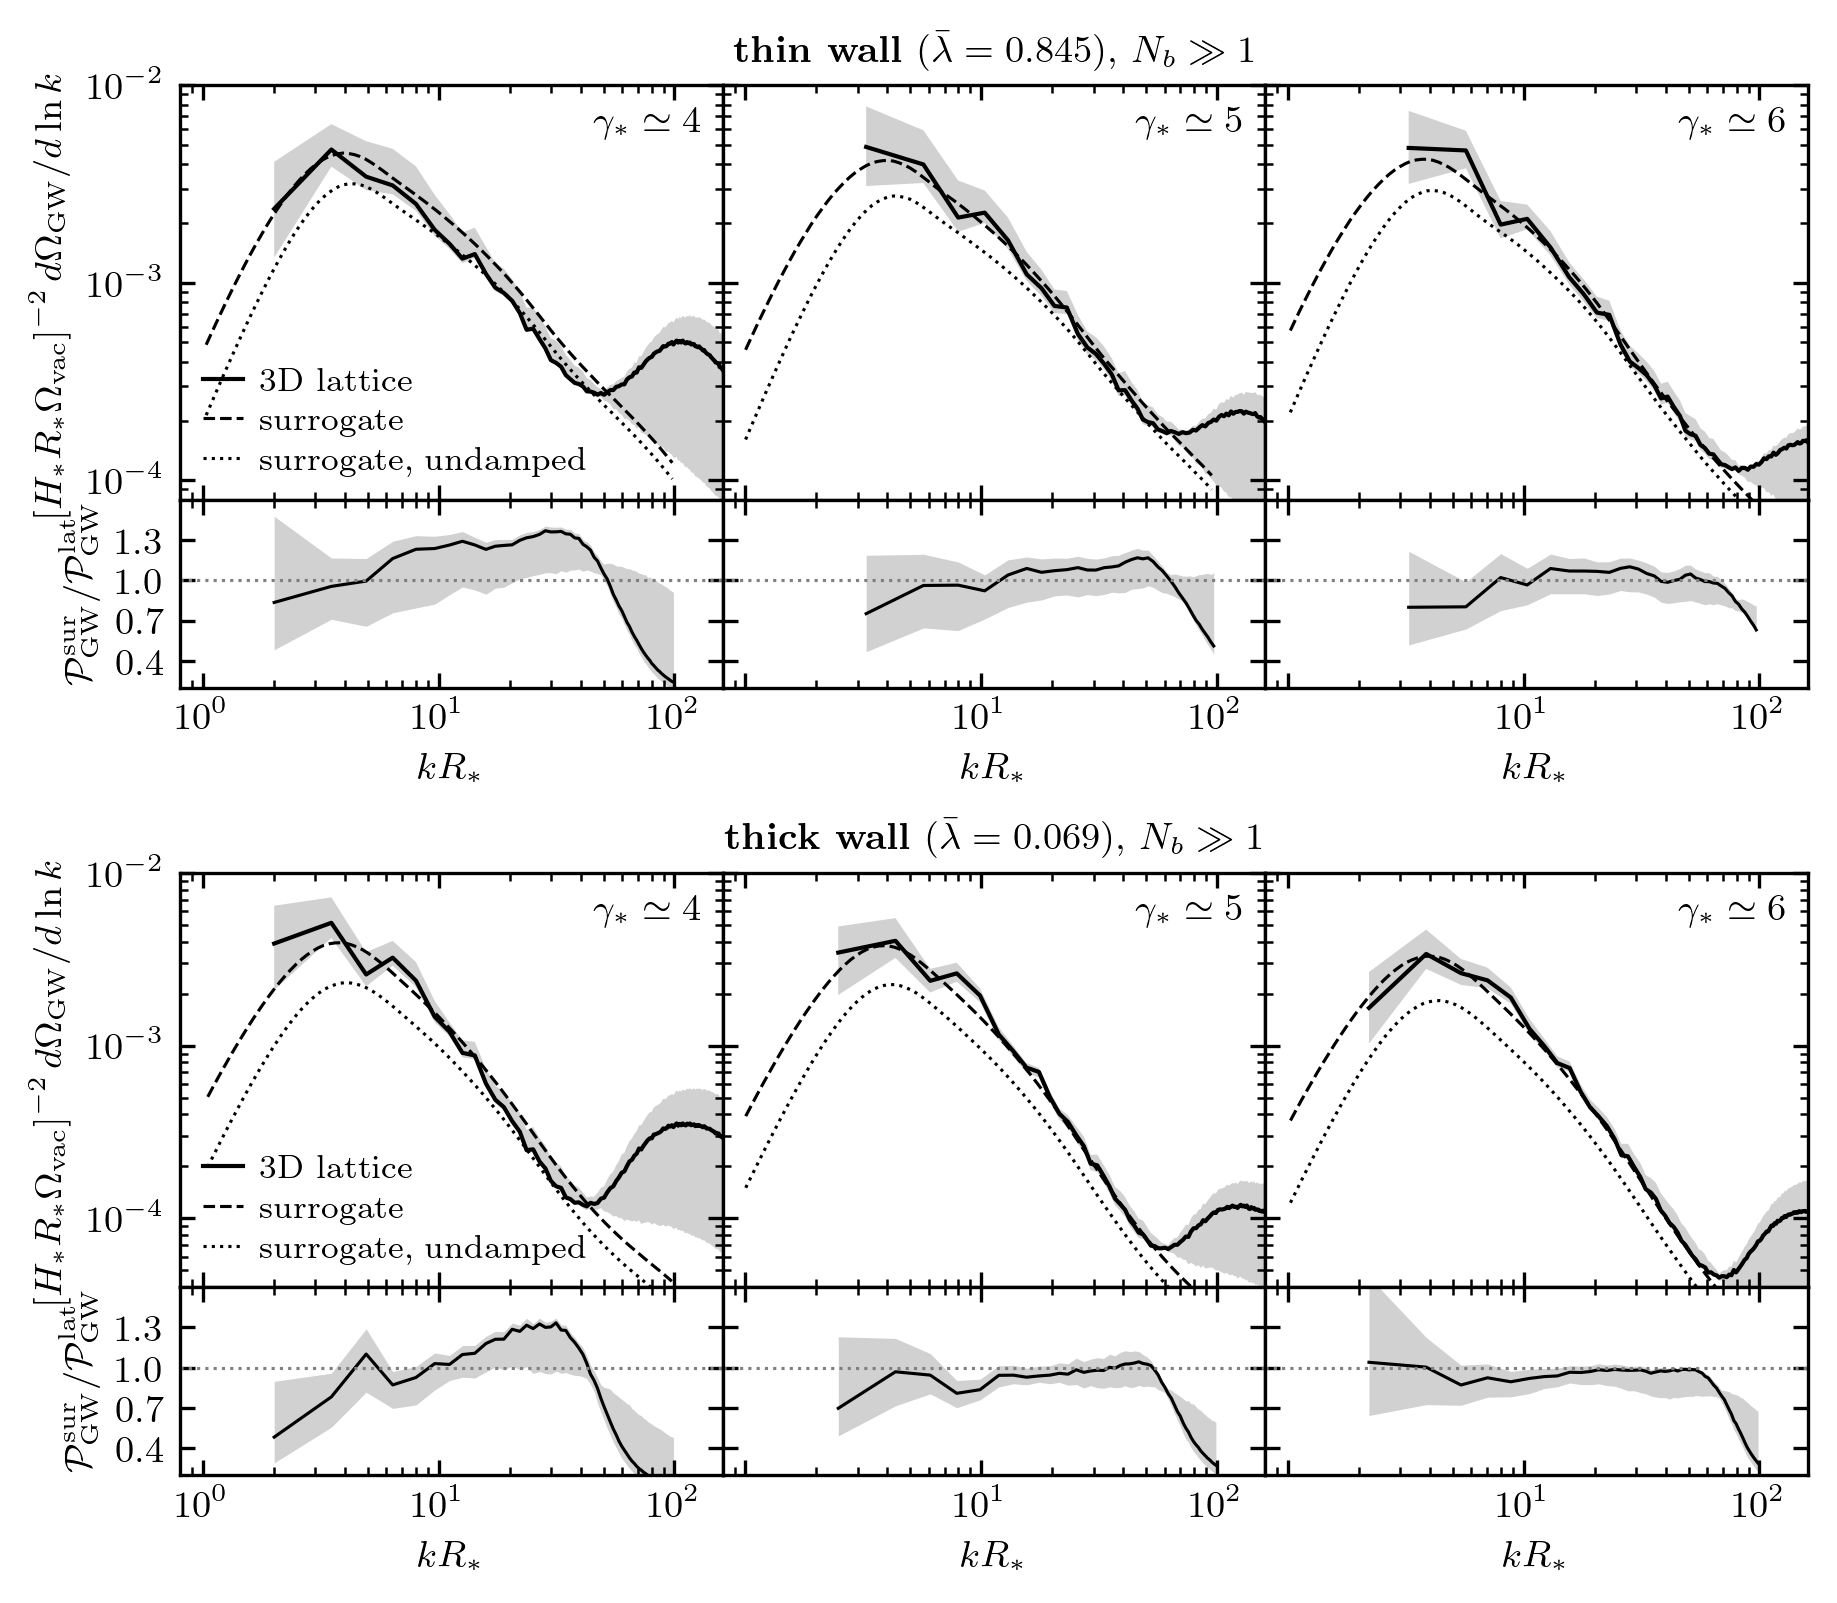

/var/folders/kq/ng576v3n1kn_dcf_r3mgn1nw0000gn/T/ipykernel_77290/1235506463.py:130: RuntimeWarning: divide by zero encountered in divide
  b.plot(x[ok], (r['I_red'] / r['I_lat'])[ok], color=cc, lw=LW_THIN)


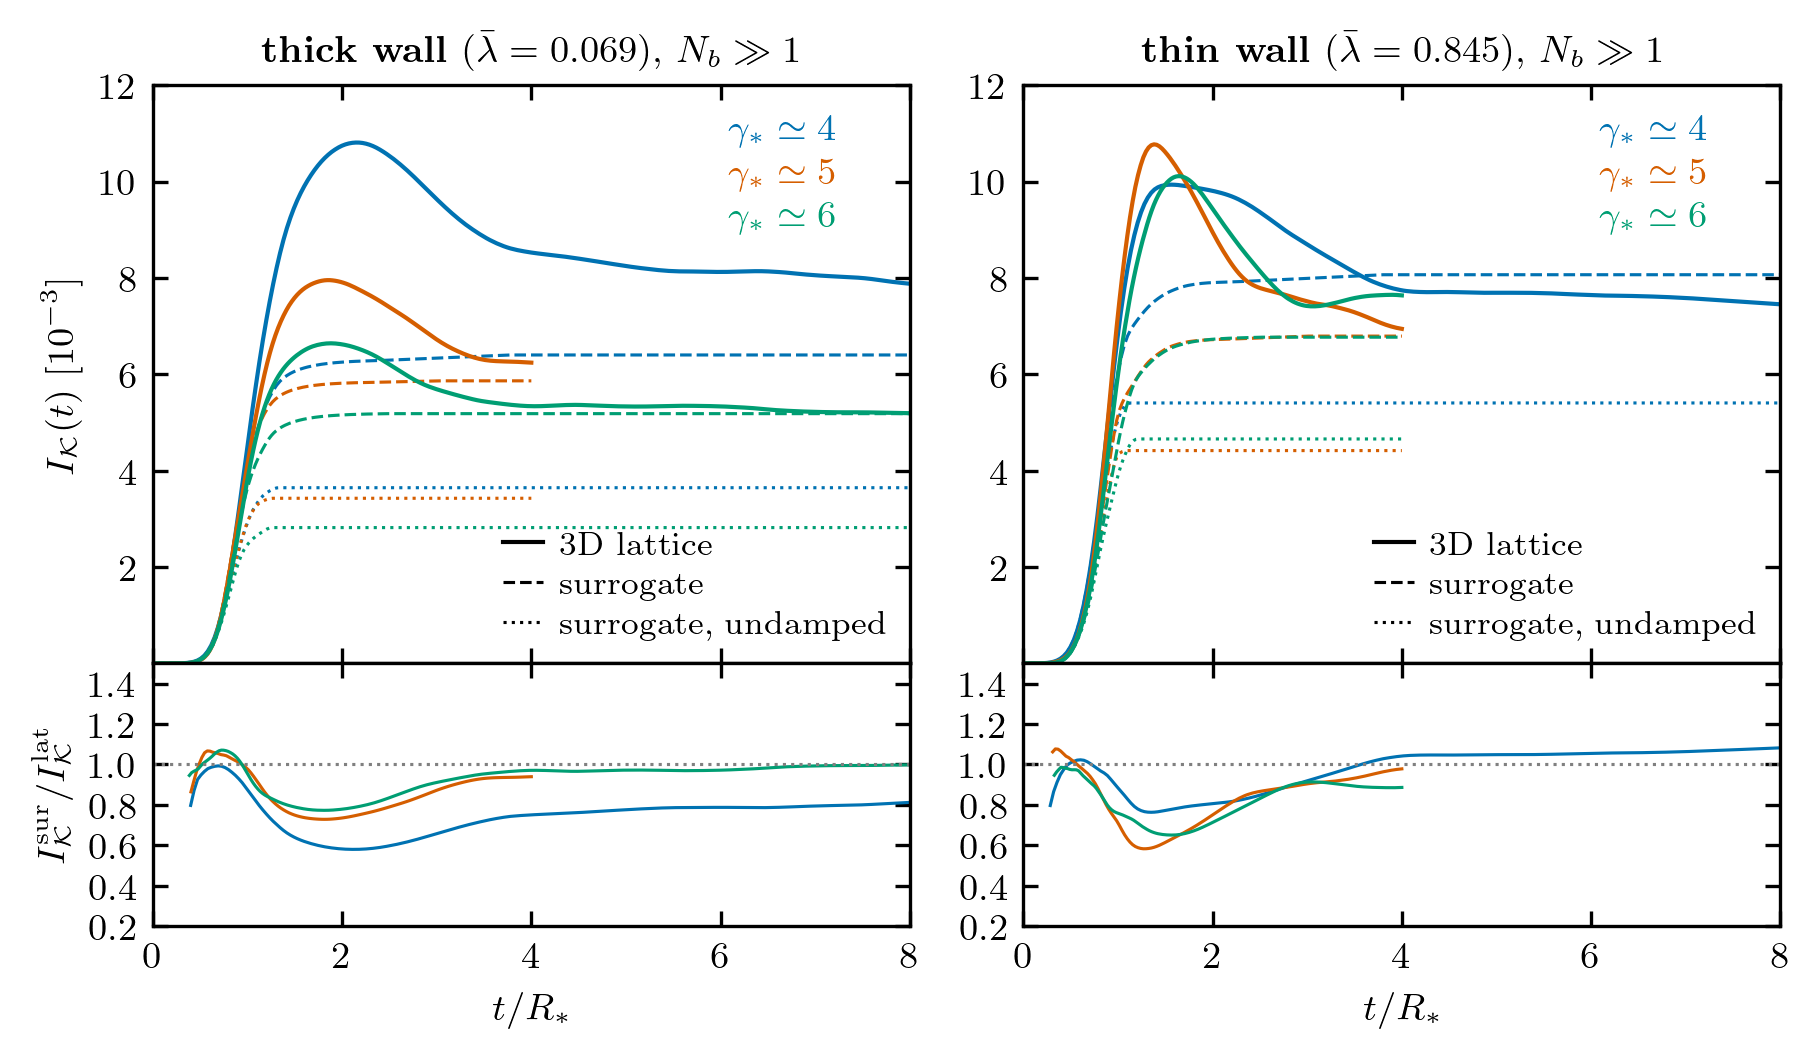

In [226]:
nm = P.cached('fig45_nmany', P.build_nmany, REBUILD)


def lattice_grid(run):
    """Grid points per side of a sledgehamr run, from its first spectrum file's header."""
    f = sorted((P.SH / run / 'gw_spectra').glob('*/spectra.hdf5'))[0]
    with P.h5py.File(f) as h:
        return int(h['Header'][1])


# ================================================================ Fig. 4: spectra
# ---------------------------------------------------------------- settings
GRID = 2048                          # only lattice runs on this grid are shown
FIGSIZE = (TEXTWIDTH, 0.75 * TEXTWIDTH)   # gives the same panel aspect ratio as Figs. 1-3
HEIGHT_RATIOS = [2.2, 1]
BLOCK_GAP = 0.0                      # extra vertical gap between the thick- and thin-wall blocks (fraction)
BLOCK_TOP = 0.918                    # top of the panels within each block (room for the block title)
BLOCK_BOTTOM = 0.153                 # bottom of the panels within each block (room for the x labels)
COLS = [4, 5, 6]                     # gamma_* per column
BLOCKS = [P.LB845, 0.069]            # lambda_bar of the top and bottom block

XLIM = (0.8, 160)
YLIM = {P.LB845: (8e-5, 1e-2),       # spectra, per block
        0.069: (4e-5, 1e-2)}
YLIM_RATIO = {P.LB845: (0.2, 1.6),
              0.069: (0.2, 1.6)}
YTICKS_RATIO = [0.4, 0.7, 1.0, 1.3]
LEGEND_LOC = 'lower left'            # legend in the left panel of each block
GAMMA_LABEL_POS = (0.96, 0.95)       # gamma_* label, axes fraction (top right)

# ---------------------------------------------------------------- data selection
SHOW = {key: r for key, r in nm.items() if lattice_grid(r['run']['sh']) == GRID}


def run_for(lb, gp):
    runs = [r for r in SHOW.values() if r['run']['lb'] == lb and r['run']['panel'] == gp]
    assert len(runs) == 1, (lb, gp, len(runs))
    return runs[0]


# ---------------------------------------------------------------- figure
fig = plt.figure(figsize=FIGSIZE)
blocks = fig.subfigures(2, 1, hspace=BLOCK_GAP)

for ib, (sub, lb) in enumerate(zip(blocks, BLOCKS)):
    axes = sub.subplots(2, 3, sharex=True, sharey='row',
                        gridspec_kw=dict(height_ratios=HEIGHT_RATIOS, wspace=0, hspace=0))
    sub.subplots_adjust(top=BLOCK_TOP, bottom=BLOCK_BOTTOM)
    axes[0, 1].set_title(rf'\textbf{{{WALL[lb]} wall}} ($\bar\lambda={LB_LABEL[lb]}$), $N_b\gg1$')

    for c, gp in enumerate(COLS):
        a, b = axes[0, c], axes[1, c]
        r = run_for(lb, gp)

        a.fill_between(r['kR_sh'], r['y_lo'], r['y_hi'], color='black', alpha=0.18, lw=0)
        a.plot(r['kR_sh'], r['y_med'], color='black', lw=LW, label='3D lattice')
        m = (r['kR_rec'] >= 1) & (r['kR_rec'] <= 100)
        a.plot(r['kR_rec'][m], r['y_rec'][m], color='black', lw=LW_THIN, ls='--', label='surrogate')
        a.plot(r['kR_rec'][m], r['y_rec_raw'][m], color='black', lw=LW_THIN, ls=LS_UNDAMPED, label='surrogate, undamped')

        x = r['kR_sh'][r['shell_mask']]
        s = r['rec_shells']
        b.fill_between(x, s / r['y_hi'][r['shell_mask']], s / r['y_lo'][r['shell_mask']],      # surrogate / lattice
                       color='black', alpha=0.18, lw=0)
        b.plot(x, s / r['y_med'][r['shell_mask']], color='black', lw=LW_THIN)
        #b.plot(x, r['rec_shells_raw'] / r['y_med'][r['shell_mask']], color='black', lw=LW_THIN, ls=LS_UNDAMPED)

        if c == 0:
            a.legend(frameon=False, loc=LEGEND_LOC)
        a.text(*GAMMA_LABEL_POS, rf'$\gamma_*\simeq{gp}$', transform=a.transAxes, ha='right', va='top')

        a.set_xscale('log')
        a.set_yscale('log')
        a.set_xlim(*XLIM)
        a.set_ylim(*YLIM[lb])

        b.axhline(1, color='gray', ls=':', lw=LW_THIN)
        b.set_ylim(*YLIM_RATIO[lb])
        b.set_yticks(YTICKS_RATIO)
        b.set_xlabel(r'$kR_*$')

        for ax in (a, b):
            ticks(ax)

    axes[0, 0].set_ylabel(YLAB)
    axes[1, 0].set_ylabel(YLAB_RATIO_SPEC)
    for c in (1, 2):
        hide_join_label(axes[1, c])

fig.savefig(OUT / 'nmany_spectra.pdf', bbox_inches='tight')
plt.show()


# ================================================================ Fig. 5: integrated power, N_b >> 1

# ---------------------------------------------------------------- settings
FIGSIZE = (TEXTWIDTH, 0.52 * TEXTWIDTH)
HEIGHT_RATIOS = [2.2, 1]
PANELS = [0.069, P.LB845]            # lambda_bar of the left and right column

XLIM = (0, 8)
XTICKS = [0, 2, 4, 6, 8]
UNIT = 1e-3                          # I_K plotted in units of UNIT
YLIM = {0.069: (0, 12),              # I_K, per column
        P.LB845: (0, 12)}
YLIM_RATIO = (0.2, 1.5)
YTICKS_RATIO = [0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4]

GAMMA_LABEL_X = 0.76                 # gamma_* labels (axes fraction), top right
GAMMA_LABEL_Y0 = 0.95
GAMMA_LABEL_DY = 0.075
LEGEND_LOC = 'lower right'

# ---------------------------------------------------------------- figure
fig, axes = plt.subplots(
    2, 2, figsize=FIGSIZE, sharex='col',
    gridspec_kw=dict(height_ratios=HEIGHT_RATIOS, hspace=0, wspace=0.15),
)

for col, lb in enumerate(PANELS):
    a, b = axes[:, col]

    for gp, cc in zip(COLS, COL3):
        r = run_for(lb, gp)
        x = r['t'] / r['R']
        a.plot(x, r['I_lat'] / UNIT, color=cc, lw=LW)
        a.plot(x, r['I_red'] / UNIT, color=cc, lw=LW_THIN, ls='--')
        a.plot(x, r['I_red_raw'] / UNIT, color=cc, lw=LW_THIN, ls=LS_UNDAMPED)
        ok = (r['I_lat'] > 1e-3 * r['I_lat'].max()) & (r['I_red'] > 1e-3 * r['I_lat'].max())
        b.plot(x[ok], (r['I_red'] / r['I_lat'])[ok], color=cc, lw=LW_THIN)
        #b.plot(x[ok], (r['I_red_raw'] / r['I_lat'])[ok], color=cc, lw=LW_THIN, ls=LS_UNDAMPED)

    # legend and labels
    a.plot([], [], color='black', lw=LW, label='3D lattice')
    a.plot([], [], color='black', lw=LW_THIN, ls='--', label='surrogate')
    a.plot([], [], color='black', lw=LW_THIN, ls=LS_UNDAMPED, label='surrogate, undamped')
    a.legend(frameon=False, loc=LEGEND_LOC)
    panel_label(a, lb, r', $N_b\gg1$')
    for i, (gp, cc) in enumerate(zip(COLS, COL3)):
        a.text(GAMMA_LABEL_X, GAMMA_LABEL_Y0 - GAMMA_LABEL_DY * i, rf'$\gamma_*\simeq{gp}$',
               color=cc, transform=a.transAxes, ha='left', va='top')

    # axes
    for ax in (a, b):
        ticks(ax)
    a.set_xlim(*XLIM)
    a.set_xticks(XTICKS)
    a.set_ylim(*YLIM[lb])
    a.set_yticks(a.get_yticks()[1:])             # drop the 0 label at the join with the ratio panel

    b.axhline(1, color='gray', ls=':', lw=LW_THIN)
    b.set_ylim(*YLIM_RATIO)
    b.set_yticks(YTICKS_RATIO)
    b.set_xlabel(r'$t/R_*$')

axes[0, 0].set_ylabel(r'$I_{\mathcal{K}}(t)\ [10^{-3}]$')
axes[1, 0].set_ylabel(YLAB_RATIO_IK)

fig.savefig(OUT / 'nmany_integrated_power.pdf', bbox_inches='tight')
plt.show()

## Fig. 6 -- predictions: $\gamma_*=20$, $N_b=512$ spectra; peak vs $\gamma_*$ ($N_b=128$); peak vs $N_b$ ($\gamma_*=20$). Solid: damped, dotted: undamped

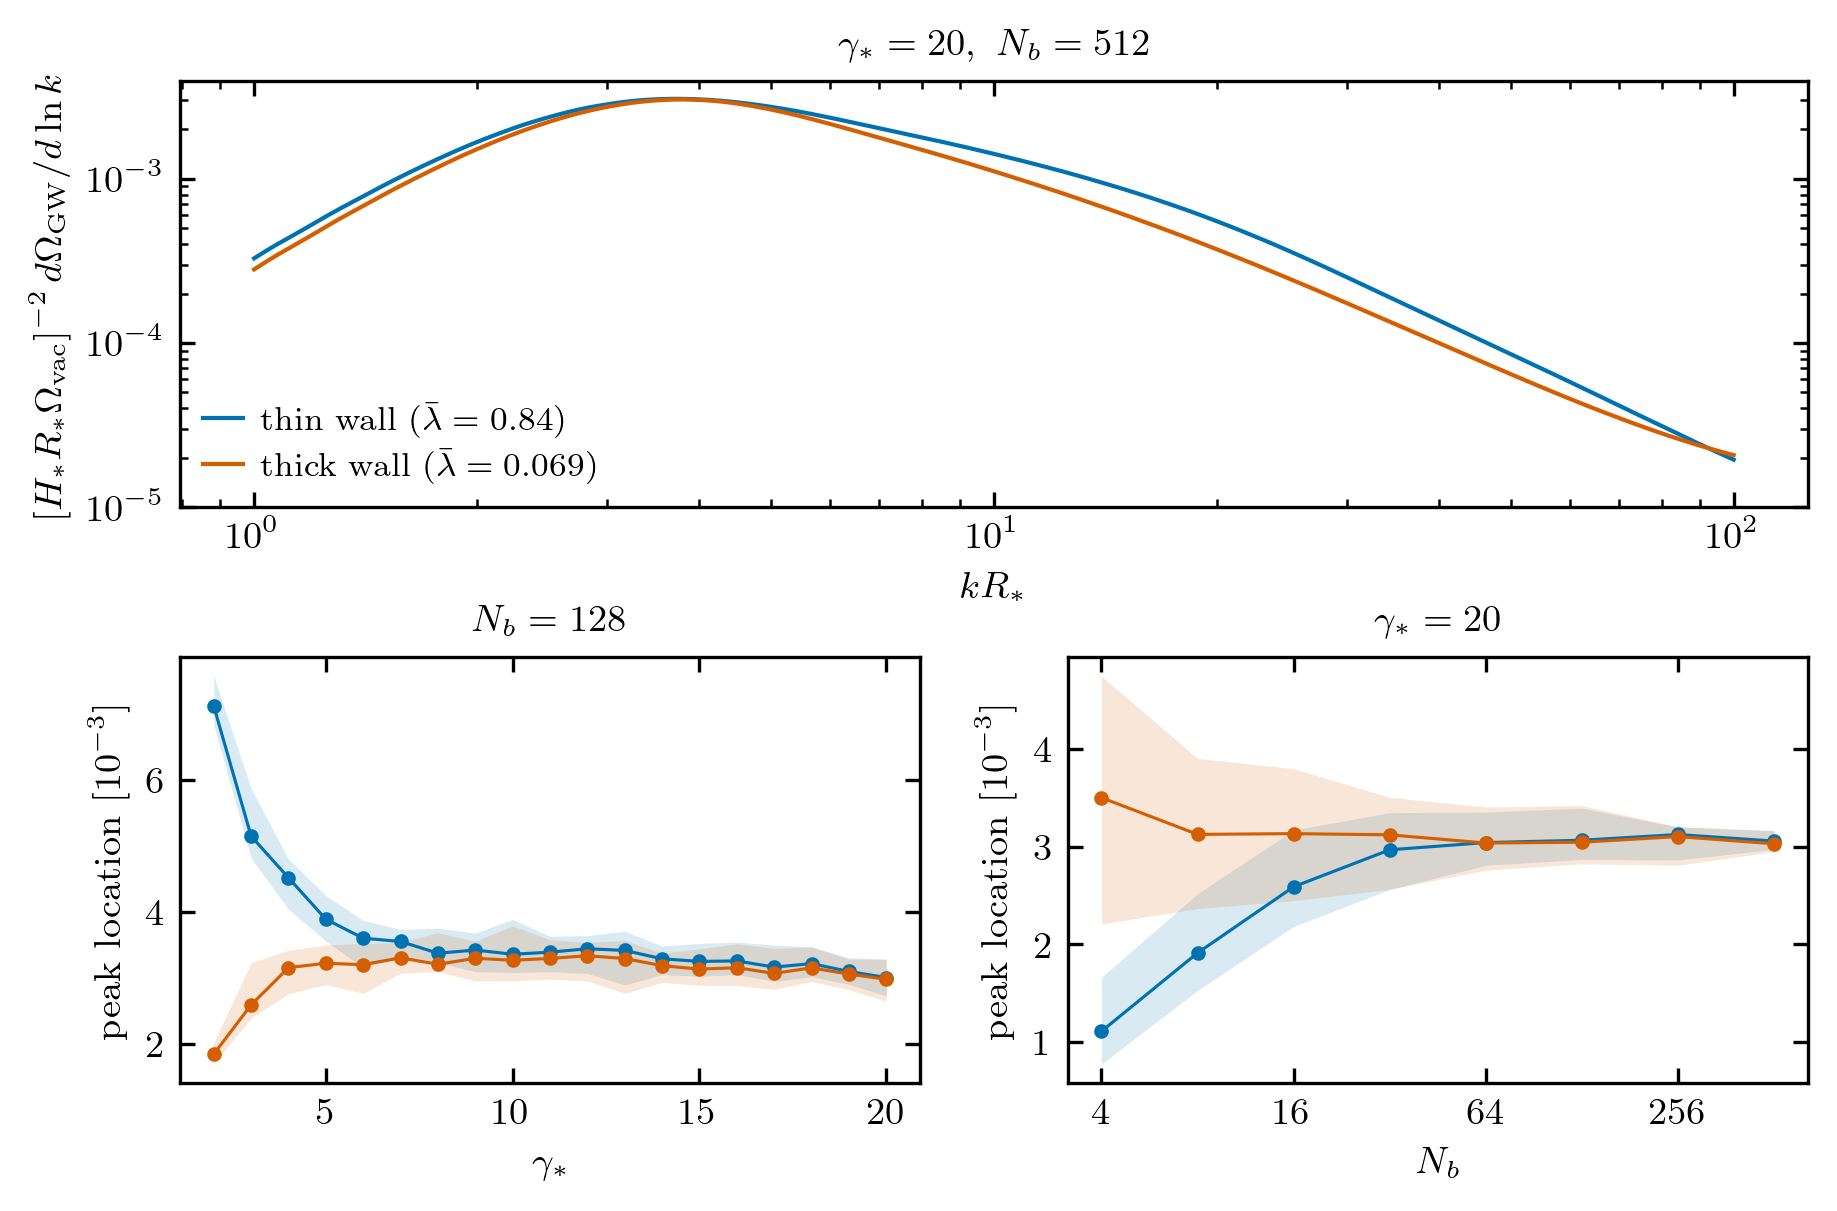

In [234]:
from ptbuilder.weight_scan_diagnostics import characteristic_scale, load_kinematics

gsf, nbf = P.load_families()

# ---------------------------------------------------------------- settings
FIGSIZE = (TEXTWIDTH, 0.75 * TEXTWIDTH)
HEIGHT_RATIOS = [1.5, 1]             # top: spectrum (full width); bottom: the two peak scans
WSPACE = 0.2
HSPACE = 0.35
TITLE_POS = (0.97, 0.94)            # panel titles, inside the axes (axes fraction, top right)
UNIT = 1e-3                          # peaks plotted in units of UNIT

LBS = [0.84, 0.069]
CL = {0.84: '#0072B2', 0.069: '#D55E00'}
NBS = [4, 8, 16, 32, 64, 128, 256, 512]
GS = list(range(2, 21))
MS = 2.5                             # marker size

YLIM_SPEC = (1e-5, None)
YLIM_PEAK = (None, None)

# ---------------------------------------------------------------- data
X = P.X_PLOT
R20 = {lb: characteristic_scale(load_kinematics(P.DATA / f'phi4_lambda_bar{lb:g}/instanton.h5'), 20.0)[1]
       for lb in LBS}


def chw(dE, R, lb, L):
    return P.to_chw(dE, R, lb, L**3)

# ---------------------------------------------------------------- figure
fig = plt.figure(figsize=FIGSIZE)
grid = fig.add_gridspec(2, 2, height_ratios=HEIGHT_RATIOS, wspace=WSPACE, hspace=HSPACE)
a0 = fig.add_subplot(grid[0, :])
a1, a2 = fig.add_subplot(grid[1, 0]), fig.add_subplot(grid[1, 1])

for lb in LBS:
    L512 = nbf[(lb, 512, 0)][0]
    for which, ls in (('damped', '-'), ('undamped', ':')):
        if which == 'undamped':
            continue
        if lb == 0.069:
            label = rf'thick wall ($\bar\lambda={lb}$)' if which == 'damped' else None
        else:
            label = rf'thin wall ($\bar\lambda={lb}$)' if which == 'damped' else None
        # left: gamma_* = 20, N_b = 512 spectrum (median of 16)
        y = chw(np.median([nbf[(lb, 512, rz)][1][which] for rz in range(16)], axis=0), R20[lb], lb, L512)
        a0.plot(X, y, color=CL[lb], ls=ls, lw=LW, label=label)

        # middle: peak vs gamma_* (N_b = 128)
        pk = [chw(np.median(gsf[(lb, s)][2][which], axis=0), gsf[(lb, s)][0], lb, gsf[(lb, s)][1]).max() for s in GS]
        a1.plot(GS, np.array(pk) / UNIT, ls=ls, marker='o' if which == 'damped' else None, ms=MS, color=CL[lb], lw=LW_THIN, label=label)
        if which == 'damped':
            pr = np.array([[chw(e, gsf[(lb, s)][0], lb, gsf[(lb, s)][1]).max() for e in gsf[(lb, s)][2][which]]
                           for s in GS])
            a1.fill_between(GS, pr.min(axis=1) / UNIT, pr.max(axis=1) / UNIT, color=CL[lb], alpha=0.15, lw=0)

        # right: peak vs N_b (gamma_* = 20)
        pk = [chw(np.median([nbf[(lb, nb, rz)][1][which] for rz in range(16)], axis=0), R20[lb], lb,
                  nbf[(lb, nb, 0)][0]).max() for nb in NBS]
        a2.plot(NBS, np.array(pk) / UNIT, ls=ls, marker='o' if which == 'damped' else None, ms=MS, color=CL[lb], lw=LW_THIN, label=label)
        if which == 'damped':
            pr = np.array([[chw(nbf[(lb, nb, rz)][1][which], R20[lb], lb, nbf[(lb, nb, rz)][0]).max()
                            for rz in range(16)] for nb in NBS])
            a2.fill_between(NBS, pr.min(axis=1) / UNIT, pr.max(axis=1) / UNIT, color=CL[lb], alpha=0.15, lw=0)

a0.set_xscale('log')
a0.set_yscale('log')
a0.set_ylim(*YLIM_SPEC)
a0.set_xlabel(r'$kR_*$')
a0.set_ylabel(YLAB)
a0.text(*TITLE_POS, r'$\gamma_*=20,\ N_b=512$', transform=a0.transAxes, ha='right', va='top')
a0.legend(frameon=False, loc='lower left')

a1.set_ylim(*YLIM_PEAK)
a1.set_xlabel(r'$\gamma_*$')
a1.set_ylabel(r'peak location $[10^{-3}]$')
a1.text(*TITLE_POS, r'$N_b=128$', transform=a1.transAxes, ha='right', va='top')

a2.set_xscale('log')
a2.set_xlabel(r'$N_b$')
a2.xaxis.set_major_locator(FixedLocator([4, 16, 64, 256]))
a2.set_xticklabels(['4', '16', '64', '256'])
a2.xaxis.set_minor_locator(NullLocator())
a2.set_ylabel(r'peak location $[10^{-3}]$')
a2.text(*TITLE_POS, r'$\gamma_*=20$', transform=a2.transAxes, ha='right', va='top')

for ax in (a0, a1, a2):
    ticks(ax)

fig.savefig(OUT / 'predictions.pdf', bbox_inches='tight')
plt.show()

## Fig. 7 -- weight-weighted distributions vs $\gamma_*$ ($N_b=128$, 16 realizations): pair $\gamma_{ij}/\gamma_*$ and last collision time $t_{\max}/R_*$
Raw and $\hat D^{3.6}$-damped weights. For damped weights $t_{\max}$ = last time the pair's weight is $\ge1\%$ of its maximum (damped weights never return exactly to zero).

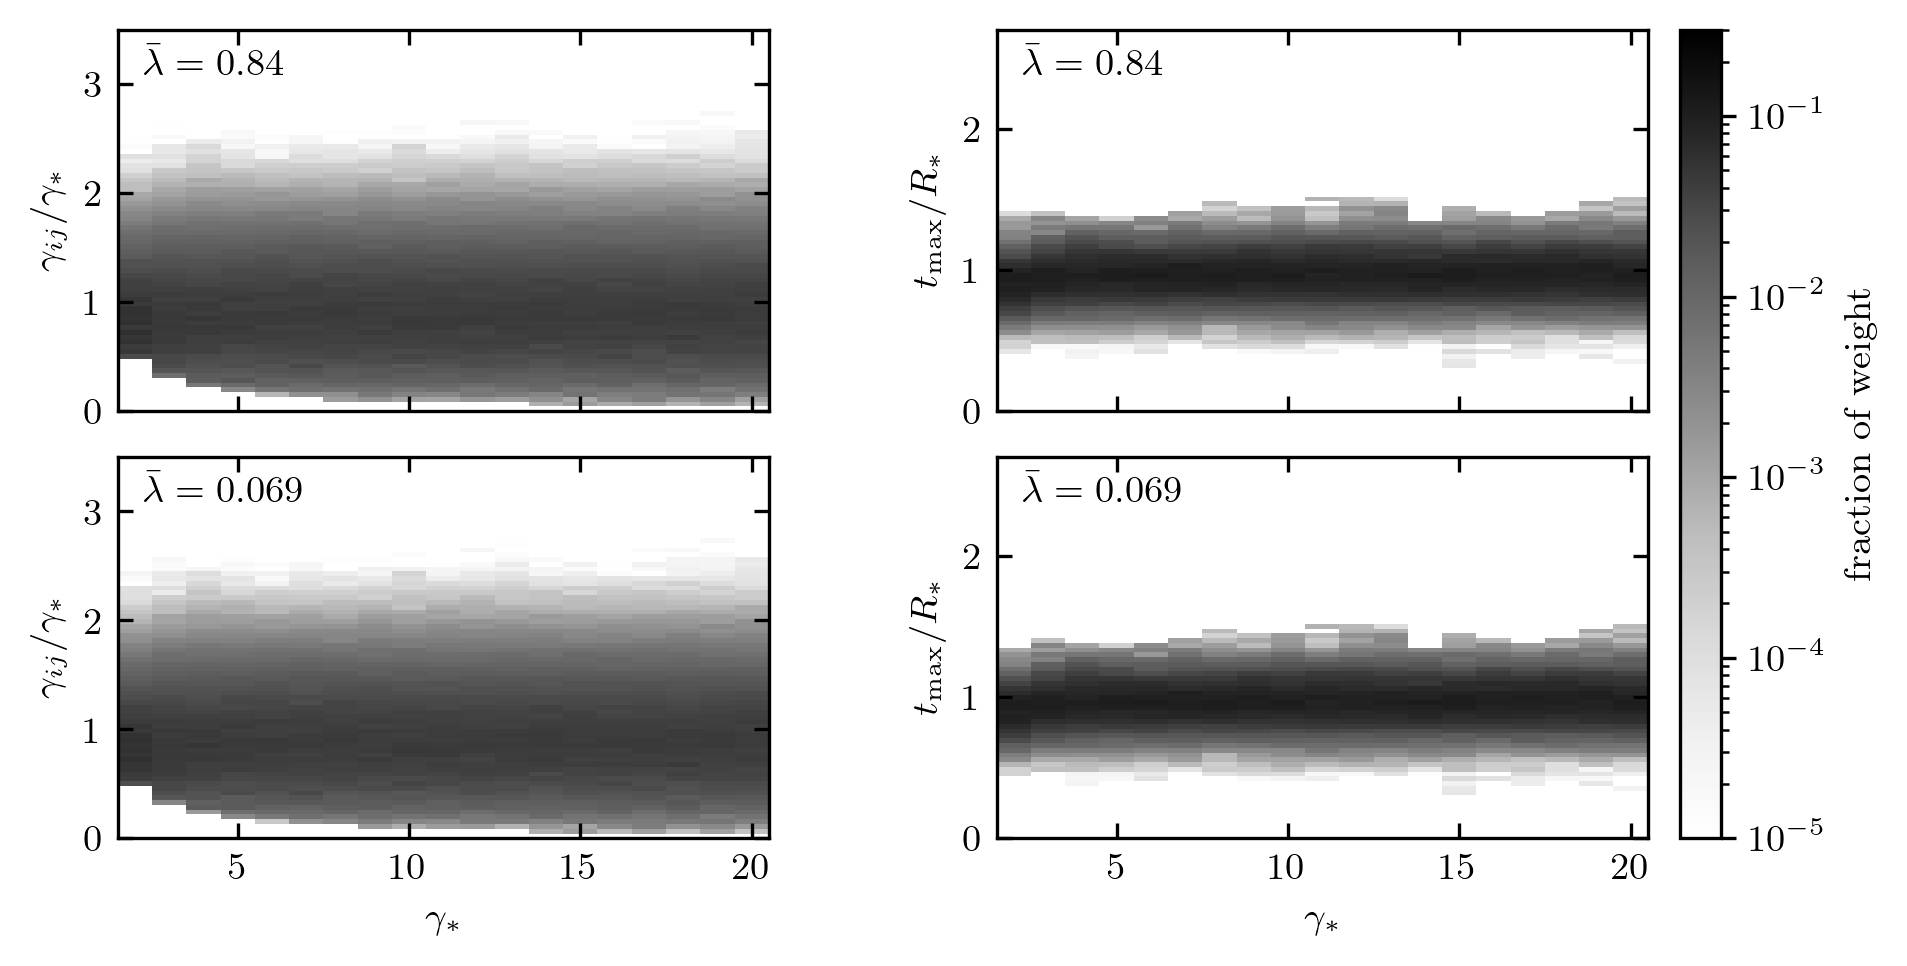

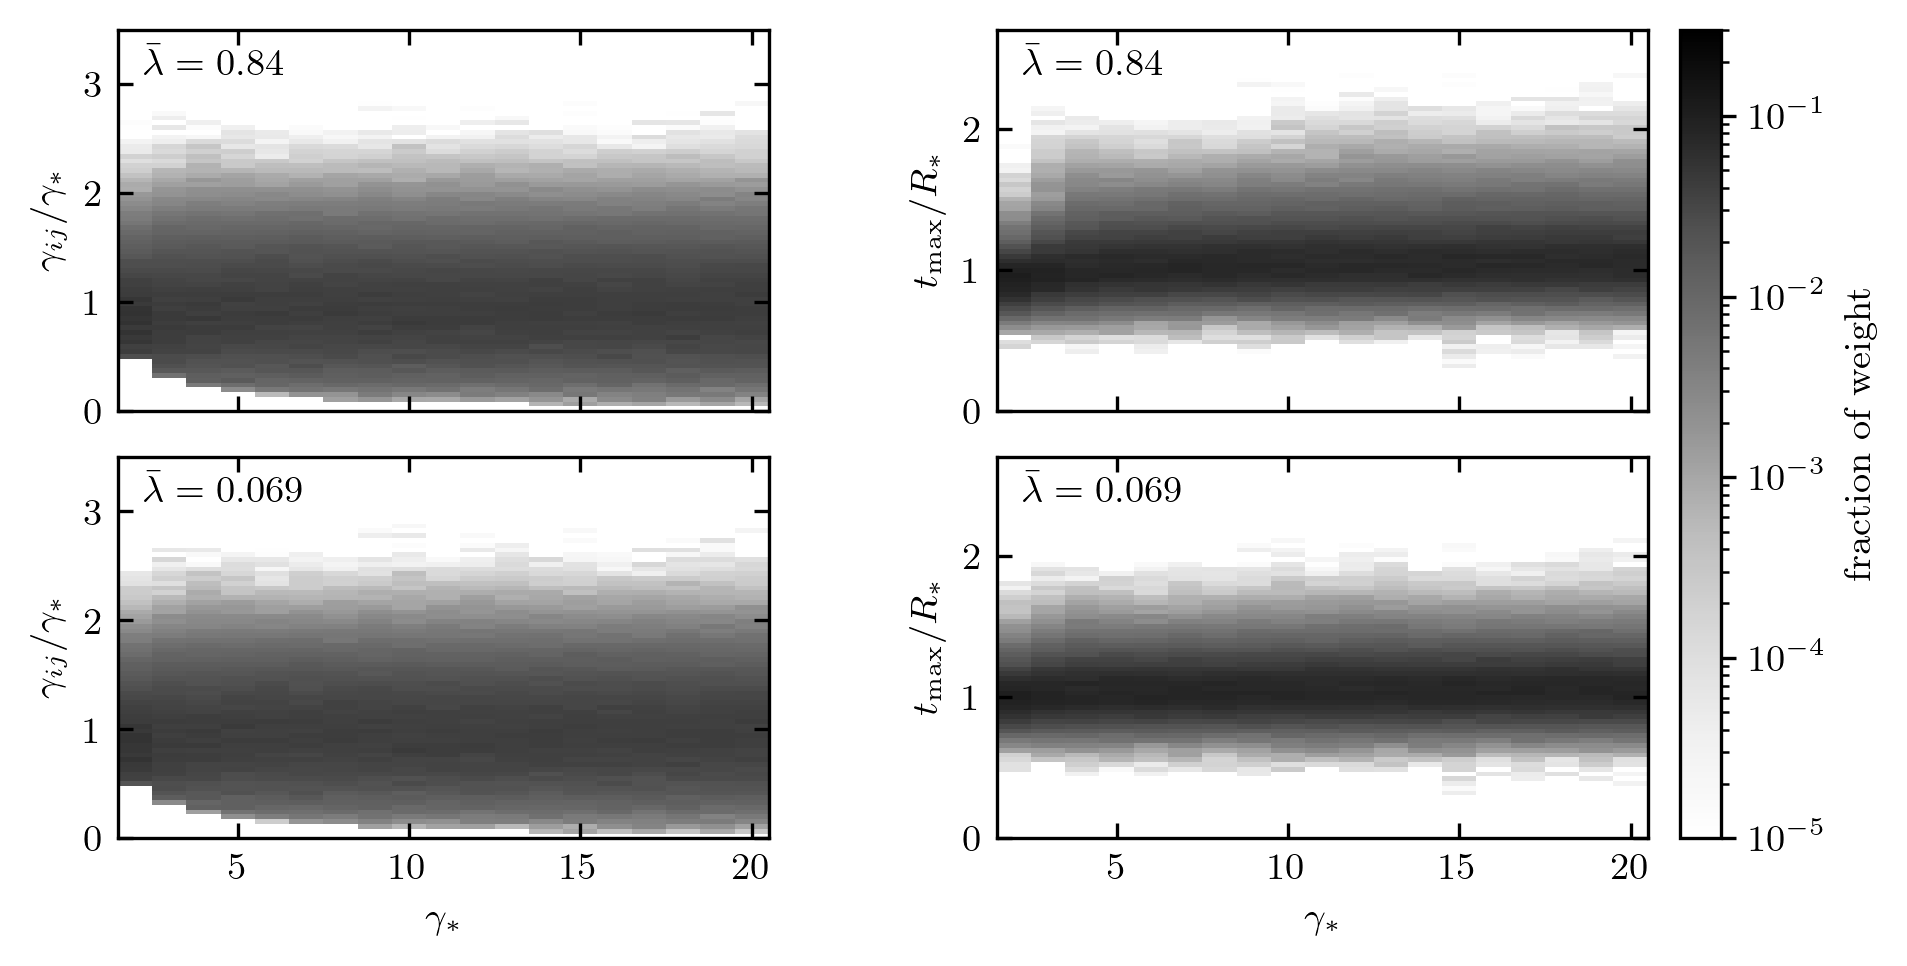

In [197]:
wh = P.cached('fig7_weight_hists', P.build_weight_hists, REBUILD)

# ---------------------------------------------------------------- settings
FIGSIZE = (TEXTWIDTH, 0.50 * TEXTWIDTH)
GS = P.GAMMA_STARS
X_EDGES = np.arange(min(GS) - 0.5, max(GS) + 1.5)
Y_EDGES = {'gamma': np.linspace(0, 3.5, 81), 'tmax': np.linspace(0, 2.7, 81)}
Y_LABEL = {'gamma': r'$\gamma_{ij}/\gamma_*$', 'tmax': r'$t_{\max}/R_*$'}
CNORM = LogNorm(1e-5, 0.3)
XTICKS = [5, 10, 15, 20]

# ---------------------------------------------------------------- figure (raw and damped weights)
for kind in ('raw', 'damp'):
    fig, axes = plt.subplots(2, 2, figsize=FIGSIZE, sharex=True, gridspec_kw=dict(hspace=0.12, wspace=0.35))

    for ir, lb in enumerate([0.84, 0.069]):
        for ic, q in enumerate(('gamma', 'tmax')):
            ye = Y_EDGES[q]
            H = np.zeros((len(ye) - 1, len(GS)))
            for ix, gs in enumerate(GS):
                d = wh[(lb, gs)]
                v = d['gamma'] / gs if q == 'gamma' else d[f'tmax_{kind}']
                W = d[f'W_{kind}']
                ok = np.isfinite(v)
                H[:, ix], _ = np.histogram(v[ok], bins=ye, weights=W[ok])
                H[:, ix] /= max(H[:, ix].sum(), 1e-300)

            ax = axes[ir, ic]
            pcm = ax.pcolormesh(X_EDGES, ye, np.where(H > 0, H, np.nan), norm=CNORM, cmap='Greys',
                                shading='flat', rasterized=True)
            ax.set_ylabel(Y_LABEL[q])
            ax.set_xticks(XTICKS)
            ax.text(0.04, 0.95, rf'$\bar\lambda={lb}$', transform=ax.transAxes, va='top')
            ticks(ax)
            if ir == 1:
                ax.set_xlabel(r'$\gamma_*$')

    fig.colorbar(pcm, ax=axes, label='fraction of weight', fraction=0.04, pad=0.02)
    fig.savefig(OUT / f'weight_distributions_{kind}.pdf', bbox_inches='tight')
    plt.show()

## Fig. 8 -- where the power comes from: $N_b=512$, $\gamma_*=20$ spectral density in $t/R_*$ and $\gamma_{ij}/\gamma_*$ (damped)

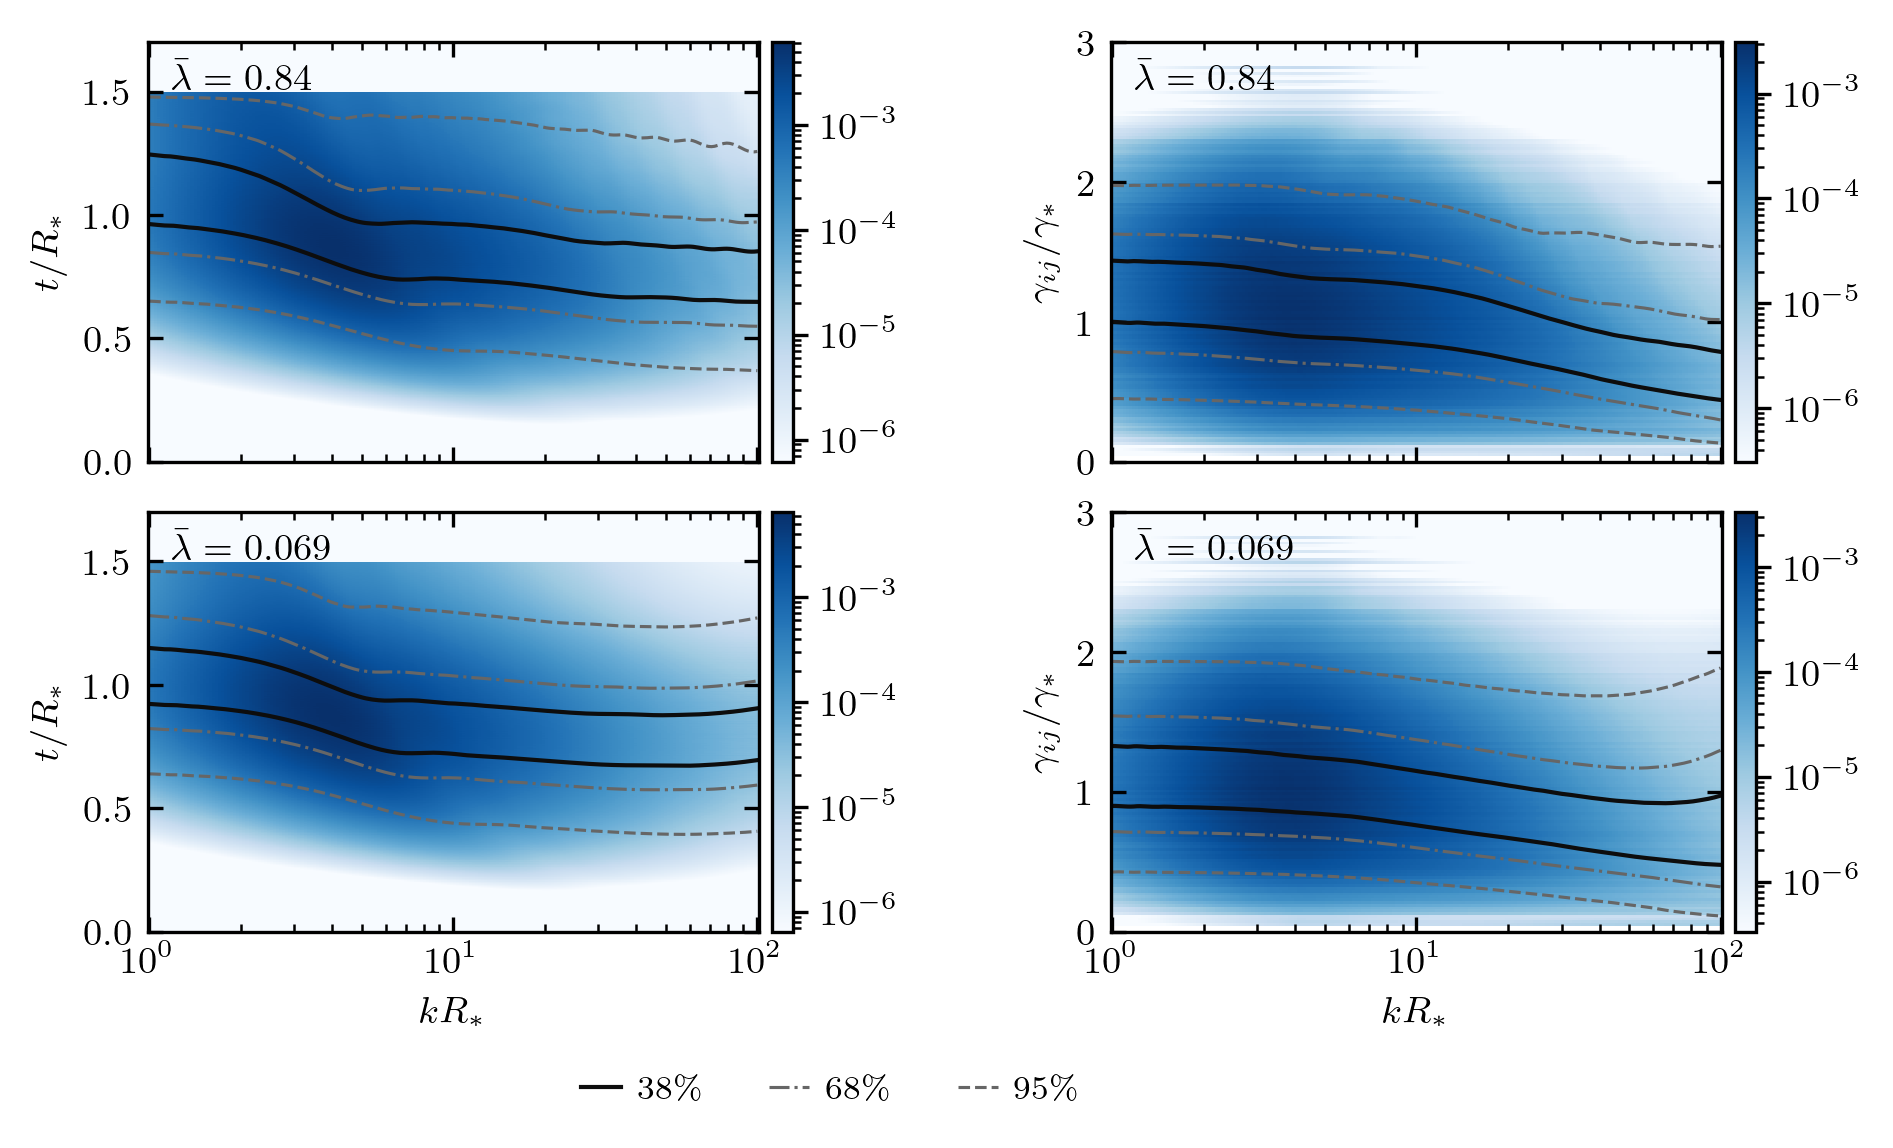

In [200]:
dec = P.cached('fig8_decomposition', P.build_decomposition, REBUILD)

# ---------------------------------------------------------------- settings
FIGSIZE = (TEXTWIDTH, 0.55 * TEXTWIDTH)
YLIM_T = (0, 1.7)
YLIM_G = (0, 3.0)
DYNAMIC_RANGE = 1e-4                 # colour scale spans [vmax * DYNAMIC_RANGE, vmax]
LEVELS = (0.383, 0.683, 0.954)
BAND_STYLE = {0.383: dict(color='0.05', lw=LW, ls='-'),
              0.683: dict(color='0.4', lw=LW_THIN, ls='-.'),
              0.954: dict(color='0.4', lw=LW_THIN, ls='--')}
BAND_LABEL = {0.383: r'38\%', 0.683: r'68\%', 0.954: r'95\%'}


def bands(H, edges, levels=LEVELS):
    """Per kR_* column: equal-tailed ranges containing `level` of the power along the vertical axis."""
    yc = 0.5 * (edges[:-1] + edges[1:])
    mass = H * np.diff(edges)[:, None]
    tot = mass.sum(axis=0)
    out = {}
    for lev in levels:
        lo, hi = np.full(H.shape[1], np.nan), np.full(H.shape[1], np.nan)
        for k in range(H.shape[1]):
            if tot[k] <= 0:
                continue
            cum = np.r_[0., np.cumsum(mass[:, k]) / tot[k]]
            yy = np.r_[edges[0], yc]
            lo[k] = np.interp(0.5 * (1 - lev), cum, yy)
            hi[k] = np.interp(1 - 0.5 * (1 - lev), cum, yy)
        out[lev] = (lo, hi)
    return out


kR = P.X_PLOT
ke = np.sqrt(kR[:-1] * kR[1:])
ke = np.r_[kR[0]**2 / ke[0], ke, kR[-1]**2 / ke[-1]]

# ---------------------------------------------------------------- figure
fig, axes = plt.subplots(2, 2, figsize=FIGSIZE, sharex=True, gridspec_kw=dict(hspace=0.12, wspace=0.45))

for ir, lb in enumerate([0.84, 0.069]):
    d = dec[lb]
    V = d['L']**3
    n = d['n_real']
    te = d['t'] / d['R']
    Ht = P.to_chw(d['h_t'] / n, d['R'], lb, V) / np.diff(te)[:, None]
    ge = d['edges_g'] / 20.0
    Hg = P.to_chw(d['h_g'] / n, d['R'], lb, V) / np.diff(ge)[:, None]

    for ic, (H, e, lab, ylim) in enumerate(((Ht, te, r'$t/R_*$', YLIM_T),
                                           (Hg, ge, r'$\gamma_{ij}/\gamma_*$', YLIM_G))):
        ax = axes[ir, ic]
        vmax = H.max()
        pcm = ax.pcolormesh(ke, e, np.maximum(H, vmax * DYNAMIC_RANGE * 1e-3),
                            norm=LogNorm(vmax * DYNAMIC_RANGE, vmax), cmap='Blues', shading='auto', rasterized=True)
        for lev, (lo, hi) in bands(H, e).items():
            ax.plot(kR, lo, label=BAND_LABEL[lev], **BAND_STYLE[lev])
            ax.plot(kR, hi, **BAND_STYLE[lev])

        ax.set_xscale('log')
        ax.set_ylim(*ylim)
        ax.set_ylabel(lab)
        ax.text(0.04, 0.95, rf'$\bar\lambda={lb}$', transform=ax.transAxes, va='top')
        ticks(ax)
        if ir == 1:
            ax.set_xlabel(r'$kR_*$')
        fig.colorbar(pcm, ax=ax, fraction=0.06, pad=0.02)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, frameon=False, loc='lower center', ncol=3, bbox_to_anchor=(0.45, -0.06))

fig.savefig(OUT / 'power_origin.pdf', bbox_inches='tight', dpi=300)
plt.show()